# Facility Location on the Adaptive Synthetic Graph

This notebook loads the synthetic dataset built from the `test4` logic, computes demand-to-hub travel costs on the adaptive coarse graph, and solves a Gurobi facility-location model.

The notebook solves the deterministic core model for `y`, `u`, and `x`. The scenario variable `w_s` from the robust formulation is left for a later extension once scenario data are defined.

In [1]:
from pathlib import Path

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from synthetic_data import build_synthetic_dataset, load_saved_synthetic_bundle


In [2]:
bundle_path = Path("data/synthetic/ukraine_synthetic_bundle.pkl")

if bundle_path.exists():
    bundle = load_saved_synthetic_bundle(bundle_path)
    print(f"Loaded saved synthetic bundle from {bundle_path}")
else:
    print("Saved synthetic bundle not found; building it now...")
    bundle = build_synthetic_dataset(generate_visuals=True)

filtered_graph = bundle["graphs"]["filtered_graph"]
CG = bundle["graphs"]["adaptive_graph"]
demand_nodes = bundle["demand_nodes"].copy()
summary = bundle["summary"]
cost_details = bundle["metadata"]["cost_details"]

print(f"Filtered road graph: {filtered_graph.number_of_nodes()} nodes, {filtered_graph.number_of_edges()} edges")
print(f"Adaptive CG: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Demand-node rows: {len(demand_nodes)}")


Loaded saved synthetic bundle from data/synthetic/ukraine_synthetic_bundle.pkl
Filtered road graph: 20244 nodes, 39254 edges
Adaptive CG: 112 nodes, 193 edges
Demand-node rows: 14


## Modeling notes

A couple of practical additions are needed to make the MIP non-trivial:

- We add a **demand satisfaction** constraint `sum_j x_ij = d_i` for each demand node `i`, otherwise the model could choose `x = 0` everywhere.
- We treat `T` as a **hard service threshold** now: demand node `i` can only send flow to hubs `j` with `c_ij <= T`.
- In practice, that is enforced by setting `x_ij = 0` whenever `c_ij > T`.
- We use `n_events` from the clustered ACLED demand nodes as the demand magnitude `d_i` by default. That is easy to swap later.

In [3]:
# Aggregate demand in case multiple snapped demand rows land on the same coarse node.
demand_df = (
    demand_nodes.groupby("coarse_node", as_index=False)
    .agg(
        demand_amount=("n_events", "sum"),
        total_fatalities=("total_fatalities", "sum"),
        plot_lat=("plot_lat", "first"),
        plot_lon=("plot_lon", "first"),
    )
    .sort_values("coarse_node")
    .reset_index(drop=True)
)

D = demand_df["coarse_node"].tolist()     # demand nodes on the adaptive graph
N = list(CG.nodes())                        # candidate facility nodes
demand = dict(zip(demand_df["coarse_node"], demand_df["demand_amount"]))
a = {j: float(CG.nodes[j]["a_i"]) for j in N}
b = {j: float(CG.nodes[j]["b_i"]) for j in N}

print("CG stats")
print("-" * 60)
print(f"Nodes: {len(N)}")
print(f"Edges: {CG.number_of_edges()}")
print(f"Demand nodes used in optimization: {len(D)}")
print(f"Total demand (sum of n_events): {sum(demand.values()):.2f}")
print(f"a_i range: {min(a.values()):.2f} to {max(a.values()):.2f}")
print(f"b_i range: {min(b.values()):.2f} to {max(b.values()):.2f}")
print("Zone counts:", pd.Series([CG.nodes[n]["zone"] for n in N]).value_counts().to_dict())

demand_df.head()


CG stats
------------------------------------------------------------
Nodes: 112
Edges: 193
Demand nodes used in optimization: 14
Total demand (sum of n_events): 118298.00
a_i range: 0.18 to 99.05
b_i range: 0.02 to 11.89
Zone counts: {'near': 64, 'mid': 42, 'far': 6}


,coarse_node,demand_amount,total_fatalities,plot_lat,plot_lon
0,0,10641,45414,46.688701,32.601620
1,4,1792,791,46.624746,30.876984
2,8,7607,4129,47.067872,33.626932
3,18,4503,2236,51.828107,31.922977
4,21,5666,145,52.001988,33.866121


In [4]:
# Compute c_ij as shortest-path travel time on the adaptive coarse graph.
# Travel times on edges are in seconds, so we convert to hours for readability.

c = {}
for i in D:
    lengths = nx.single_source_dijkstra_path_length(CG, i, weight="travel_time")
    for j in N:
        if j not in lengths:
            raise ValueError(f"Demand node {i} cannot reach candidate node {j} on the adaptive graph")
        c[(i, j)] = float(lengths[j] / 3600.0)

cost_matrix = pd.DataFrame(
    [[c[(i, j)] for j in N] for i in D],
    index=D,
    columns=N,
)

print("Travel-time matrix stats (hours)")
print("-" * 60)
print(f"min = {cost_matrix.min().min():.3f}")
print(f"mean = {cost_matrix.values.mean():.3f}")
print(f"max = {cost_matrix.max().max():.3f}")

cost_matrix.iloc[: min(5, len(D)), : min(8, len(N))]


Travel-time matrix stats (hours)
------------------------------------------------------------
min = 0.000
mean = 1.182
max = 3.123


,0,1,2,3,4,5,6,7
0,0.000000,1.167035,0.478331,0.676337,0.816662,0.473603,1.378635,1.007888
4,0.816662,0.490747,1.294993,1.194737,0.000000,1.290265,2.195298,1.824550
8,0.987455,0.778761,0.509124,1.663792,1.269508,1.461058,1.409429,1.038681
18,1.337586,0.996479,1.815917,1.856034,0.661298,1.811190,2.716222,2.345474
21,1.744479,1.403372,2.222810,2.262927,1.068190,2.218082,3.123115,2.752367


In [ ]:
# Core deterministic facility-location MIP
# ----------------------------------------
# min sum_j (a_j y_j + b_j u_j)
# s.t.
#   u_j <= M y_j
#   sum_i x_ij <= u_j
#   sum_j x_ij = d_i                  for each demand i
#   x_ij = 0                          whenever c_ij > T
#
# T is a hard per-assignment travel-time threshold in hours.

total_demand = float(sum(demand.values()))
M = total_demand
T = 4   # hard travel-time threshold in hours; tune later

feasible_hubs = {i: [j for j in N if c[(i, j)] <= T] for i in D}
feasible_counts = {i: len(feasible_hubs[i]) for i in D}
print("Feasible hub-count stats within T")
print("-" * 60)
print(f"min = {min(feasible_counts.values())}")
print(f"mean = {np.mean(list(feasible_counts.values())):.2f}")
print(f"max = {max(feasible_counts.values())}")

uncovered_demand_nodes = [i for i in D if feasible_counts[i] == 0]
if uncovered_demand_nodes:
    raise RuntimeError(
        "Hard threshold T leaves some demand nodes uncovered. "
        f"Increase T or adjust the graph. Uncovered demand nodes: {uncovered_demand_nodes}"
    )

model = gp.Model("adaptive_facility_location")

y = model.addVars(N, vtype=GRB.BINARY, name="y")
u = model.addVars(N, lb=0.0, vtype=GRB.CONTINUOUS, name="u")
x = model.addVars(D, N, lb=0.0, vtype=GRB.CONTINUOUS, name="x")

model.setObjective(
    gp.quicksum(a[j] * y[j] + b[j] * u[j] for j in N),
    GRB.MINIMIZE,
)

# [1] Capacity can only be provisioned at opened facilities.
model.addConstrs((u[j] <= M * y[j] for j in N), name="open_capacity_link")

# [2] Total assigned demand into facility j cannot exceed provisioned capacity u_j.
model.addConstrs((gp.quicksum(x[i, j] for i in D) <= u[j] for j in N), name="facility_capacity")

# Every demand node must be fully served.
model.addConstrs((gp.quicksum(x[i, j] for j in N) == demand[i] for i in D), name="demand_balance")

# [3] Hard service threshold: no assignment may exceed T hours.
model.addConstrs(
    (x[i, j] == 0.0 for i in D for j in N if c[(i, j)] > T),
    name="hard_service_threshold",
)

model.Params.OutputFlag = 1
model.optimize()

print("\nModel status:", model.Status)
print(f"Objective value: {model.ObjVal:.3f}" if model.SolCount > 0 else "No feasible solution found")
print(f"T = {T:.2f} hours, M = {M:.2f}")


Feasible hub-count stats within T
------------------------------------------------------------
min = 6
mean = 41.79
max = 92
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2788119
Academic license 2788119 - for non-commercial use only - registered to so___@usc.edu
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Academic license 2788119 - for non-commercial use only - registered to so___@usc.edu
Optimize a model with 1221 rows, 1792 columns and 4455 nonzeros (Min)
Model fingerprint: 0xb2ae8a55
Model has 224 linear objective coefficients
Variable types: 1680 continuous, 112 integer (112 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+05]
  Objective range  [2e-02, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [5e+02, 3e+04]

Found heuristic solution

In [6]:
if model.SolCount == 0:
    raise RuntimeError("Gurobi did not return a feasible solution. Try relaxing T.")

open_hubs = [j for j in N if y[j].X > 0.5]
hub_capacity = {j: u[j].X for j in open_hubs}
assignment_rows = []
for i in D:
    for j in N:
        flow = x[i, j].X
        if flow > 1e-6:
            assignment_rows.append(
                {
                    "demand_node": i,
                    "hub_node": j,
                    "flow": flow,
                    "travel_time_hr": c[(i, j)],
                }
            )

assignments = pd.DataFrame(assignment_rows).sort_values(["demand_node", "flow"], ascending=[True, False])
primary_assignments = assignments.drop_duplicates(subset=["demand_node"]).copy()

avg_travel_time = sum(c[(i, j)] * x[i, j].X for i in D for j in N) / total_demand
max_assigned_travel_time = max((row["travel_time_hr"] for row in assignment_rows), default=0.0)
used_capacity = {j: sum(x[i, j].X for i in D) for j in open_hubs}

print("Solution summary")
print("-" * 60)
print(f"Opened hubs: {len(open_hubs)} / {len(N)}")
print(f"Average weighted travel time: {avg_travel_time:.3f} hr")
print(f"Maximum assigned travel time: {max_assigned_travel_time:.3f} hr")
print(f"Total fixed cost: {sum(a[j] * y[j].X for j in N):.3f}")
print(f"Total capacity cost: {sum(b[j] * u[j].X for j in N):.3f}")
print(f"Total objective: {model.ObjVal:.3f}")

print("\nOpened hubs")
for j in sorted(open_hubs, key=lambda node: hub_capacity[node], reverse=True):
    attrs = CG.nodes[j]
    print(
        f"  Hub {j}: capacity={hub_capacity[j]:.2f}, used={used_capacity[j]:.2f}, "
        f"a_i={attrs['a_i']:.2f}, b_i={attrs['b_i']:.2f}, zone={attrs['zone']}, members={attrs['member_count']}"
    )

print("\nTop primary assignments")
display(primary_assignments.head(10))


Solution summary
------------------------------------------------------------
Opened hubs: 2 / 112
Average weighted travel time: 0.704 hr
Maximum assigned travel time: 0.990 hr
Total fixed cost: 66.423
Total capacity cost: 62903.245
Total objective: 62969.668

Opened hubs
  Hub 114: capacity=110691.00, used=110691.00, a_i=0.18, b_i=0.02, zone=far, members=10456
  Hub 1: capacity=7607.00, used=7607.00, a_i=66.24, b_i=7.95, zone=near, members=1

Top primary assignments


,demand_node,hub_node,flow,travel_time_hr
0,0,114,10641.0,0.754071
1,4,114,1792.0,0.077783
2,8,1,7607.0,0.778761
3,18,114,4503.0,0.583515
4,21,114,5666.0,0.990408
5,29,114,6063.0,0.869586
6,33,114,8661.0,0.092711
7,34,114,5616.0,0.864480
8,43,114,10624.0,0.762798
9,44,114,4702.0,0.304563


/var/folders/dr/xp_zz5ls1tjf54gxzsbf2g55q3psbz/T/ipykernel_49577/2291824753.py:121: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


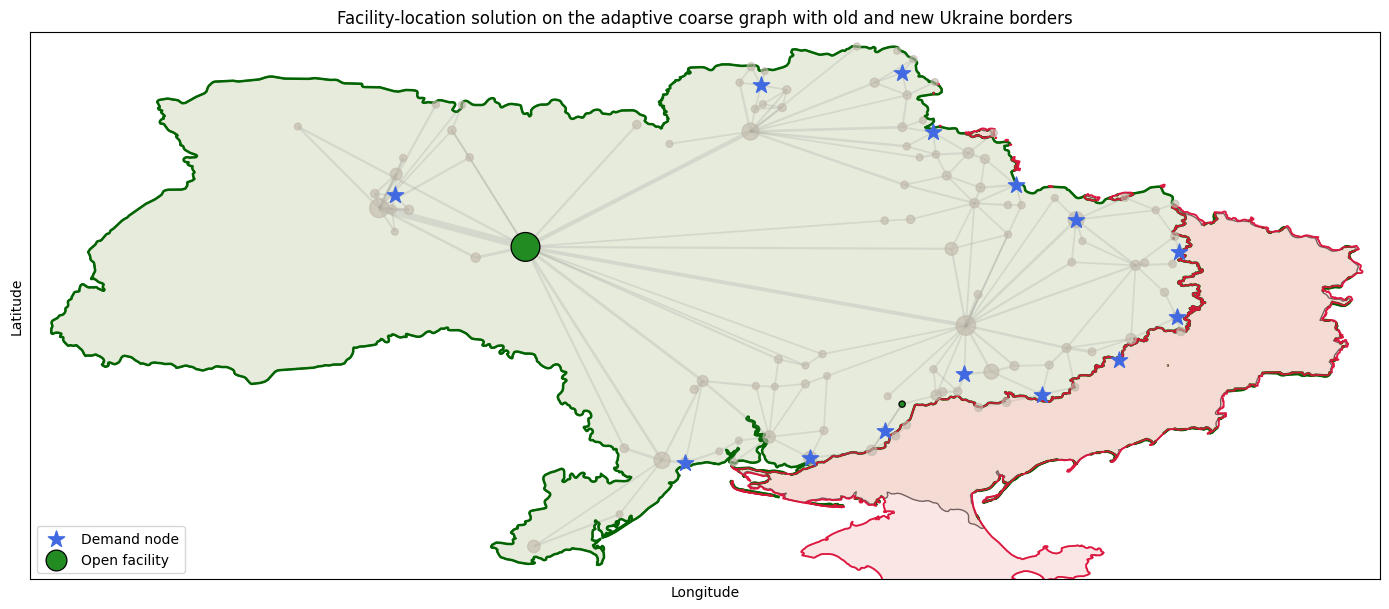

In [7]:
# Visualize the facility-location solution on the adaptive graph style,
# and add the old Ukraine land area, the occupied area, and the new sovereign-held border.

from synthetic_data.config import load_config
from synthetic_data.occupied import load_current_occupied_snapshot, load_ukraine_sovereign_geometry

config = load_config()
occupied = load_current_occupied_snapshot(config)
borders = load_ukraine_sovereign_geometry(config, occupied["occupied_geom"])

adaptive_pos = {n: (CG.nodes[n]["lon"], CG.nodes[n]["lat"]) for n in CG.nodes()}
fig, ax = plt.subplots(figsize=(14, 9))

borders["ukraine_shape"].plot(
    ax=ax,
    color="#f2ecdf",
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    zorder=0,
    label="Ukraine land area (old border)",
)
occupied["occupied_gs"].plot(
    ax=ax,
    color="#f7c8c8",
    alpha=0.45,
    edgecolor="crimson",
    linewidth=1.2,
    zorder=0.4,
    label="Occupied area",
)
borders["sovereign_shape"].plot(
    ax=ax,
    color="#dfead9",
    alpha=0.55,
    edgecolor="darkgreen",
    linewidth=1.5,
    zorder=0.8,
    label="Ukraine sovereign-held area (new border)",
)
borders["sovereign_border_gs"].plot(
    ax=ax,
    color="darkgreen",
    linewidth=1.8,
    alpha=0.95,
    zorder=1.0,
)
occupied["occupied_gs"].boundary.plot(
    ax=ax,
    color="crimson",
    linewidth=1.3,
    alpha=0.95,
    zorder=1.1,
)

edge_list = list(CG.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list] or [1]
edge_widths = [
    0.6 + 4.4 * np.sqrt(d.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, d in edge_list
]
edge_collection = nx.draw_networkx_edges(
    CG,
    adaptive_pos,
    ax=ax,
    edgelist=[(u, v) for u, v, _ in edge_list],
    edge_color="gray",
    alpha=0.18,
    width=edge_widths,
)
edge_collection.set_zorder(2)

base_node_sizes = {n: 20 + 4 * np.sqrt(CG.nodes[n].get("member_count", 1)) for n in CG.nodes()}
base_node_collection = nx.draw_networkx_nodes(
    CG,
    adaptive_pos,
    ax=ax,
    node_size=[base_node_sizes[n] for n in CG.nodes()],
    node_color="#bfb7a9",
    alpha=0.60,
)
base_node_collection.set_zorder(3)

ax.scatter(
    demand_df["plot_lon"],
    demand_df["plot_lat"],
    marker="*",
    c="royalblue",
    s=150,
    zorder=5,
    label="Demand node",
)

if open_hubs:
    max_capacity = max(hub_capacity.values()) if hub_capacity else 1.0
    hub_x = [CG.nodes[j]["lon"] for j in open_hubs]
    hub_y = [CG.nodes[j]["lat"] for j in open_hubs]
    hub_s = []
    for j in open_hubs:
        base_size = base_node_sizes[j]
        scale = np.sqrt(max(hub_capacity[j], 0.0) / max(max_capacity, 1e-9))
        hub_s.append(base_size * (0.75 + 0.25 * scale))
    ax.scatter(
        hub_x,
        hub_y,
        s=hub_s,
        c="forestgreen",
        edgecolors="black",
        linewidths=0.9,
        zorder=6,
        label="Open facility",
    )

xmin, ymin, xmax, ymax = borders["ukraine_shape"].total_bounds
ax.set_xlim(xmin - 0.3, xmax + 0.3)
ax.set_ylim(ymin - 0.2, ymax + 0.2)
ax.set_title("Facility-location solution on the adaptive coarse graph with old and new Ukraine borders")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
